In [3]:
pip install yfinance pandas matplotlib seaborn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.5 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=3477e0668d146641139970ae4420b442457f6ba8b29ee52d4104abe8dea3fb08
  Stored in directory: c:\users\divya\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking
Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [7]:
# Top 10 S&P 500 stocks across sectors
tickers = {
    "AAPL": "Technology",
    "MSFT": "Technology",
    "JPM": "Financials",
    "BAC": "Financials",
    "JNJ": "Healthcare",
    "PFE": "Healthcare",
    "XOM": "Energy",
    "CVX": "Energy",
    "AMZN": "Consumer Discretionary",
    "WMT": "Consumer Staples"
}

raw = yf.download(list(tickers.keys()), start="2020-01-01", end="2024-12-31", auto_adjust=True)
df = raw["Close"].copy()
print(df.shape)
df.head()

[*********************100%***********************]  10 of 10 completed

(1257, 10)


Ticker,AAPL,AMZN,BAC,CVX,JNJ,JPM,MSFT,PFE,WMT,XOM
Date,,,,,,,,,,
2020-01-02,72.400513,94.900497,30.587559,92.017723,122.638245,119.036446,152.158401,27.494843,36.359215,53.306416
2020-01-03,71.696640,93.748497,29.952465,91.699478,121.218369,117.465546,150.263748,27.347324,36.038239,52.877842
2020-01-06,72.267937,95.143997,29.909557,91.388748,121.067108,117.372154,150.652176,27.312202,35.964867,53.283852
2020-01-07,71.928062,95.343002,29.712162,90.221794,121.806473,115.376793,149.278534,27.220881,35.631657,52.847778
2020-01-08,73.085114,94.598503,30.012535,89.191208,121.789680,116.276810,151.656296,27.438643,35.509388,52.050819


In [9]:
# Check for nulls
print("Null values:\n", df.isnull().sum())

# Forward fill minor gaps
df.ffill(inplace=True)

# Add sector mapping
sector_map = pd.Series(tickers, name="Sector")
print("\nData range:", df.index.min(), "to", df.index.max())
print("Stocks:", df.columns.tolist())

Null values:
 Ticker
AAPL    0
AMZN    0
BAC     0
CVX     0
JNJ     0
JPM     0
MSFT    0
PFE     0
WMT     0
XOM     0
dtype: int64

Data range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00
Stocks: ['AAPL', 'AMZN', 'BAC', 'CVX', 'JNJ', 'JPM', 'MSFT', 'PFE', 'WMT', 'XOM']


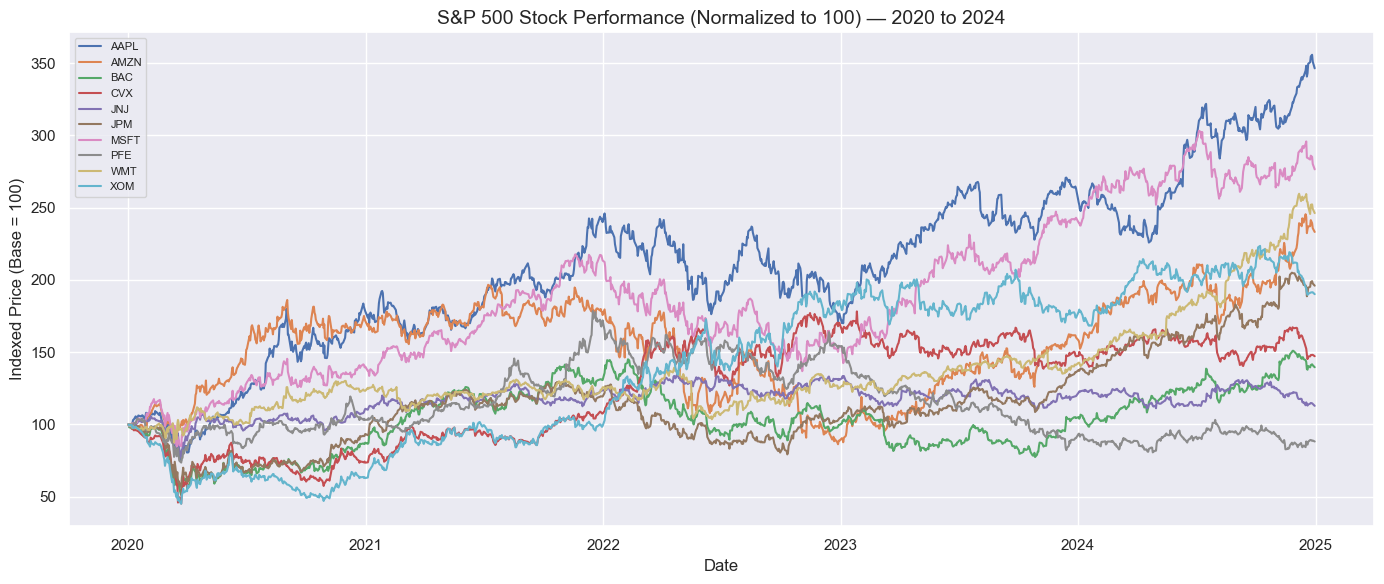

In [11]:
# Normalize to 100 at start date for fair comparison
normalized = (df / df.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

plt.title("S&P 500 Stock Performance (Normalized to 100) — 2020 to 2024", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Indexed Price (Base = 100)")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("normalized_price_trend.png", dpi=150)
plt.show()

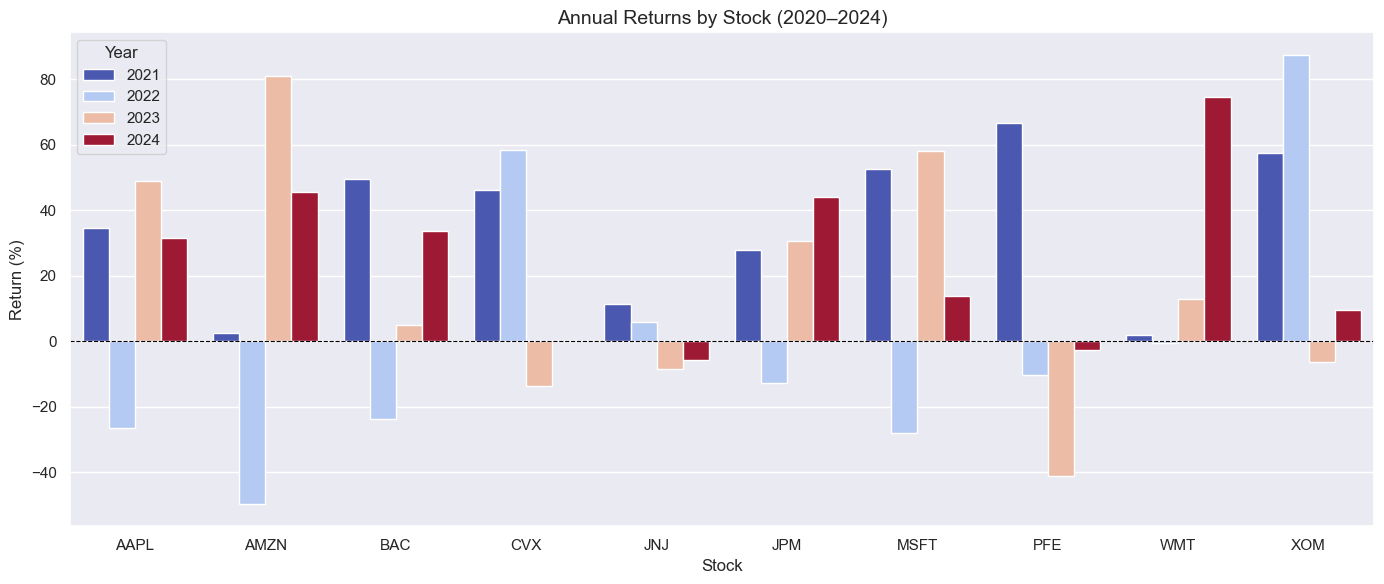

In [13]:
# Calculate yearly % return
annual_returns = df.resample("YE").last().pct_change() * 100
annual_returns = annual_returns.dropna()
annual_returns.index = annual_returns.index.year

# Melt for seaborn
returns_melted = annual_returns.reset_index().melt(id_vars="Date", var_name="Stock", value_name="Return (%)")
returns_melted.rename(columns={"Date": "Year"}, inplace=True)

plt.figure(figsize=(14, 6))
sns.barplot(data=returns_melted, x="Stock", y="Return (%)", hue="Year", palette="coolwarm")
plt.title("Annual Returns by Stock (2020–2024)", fontsize=14)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("annual_returns.png", dpi=150)
plt.show()

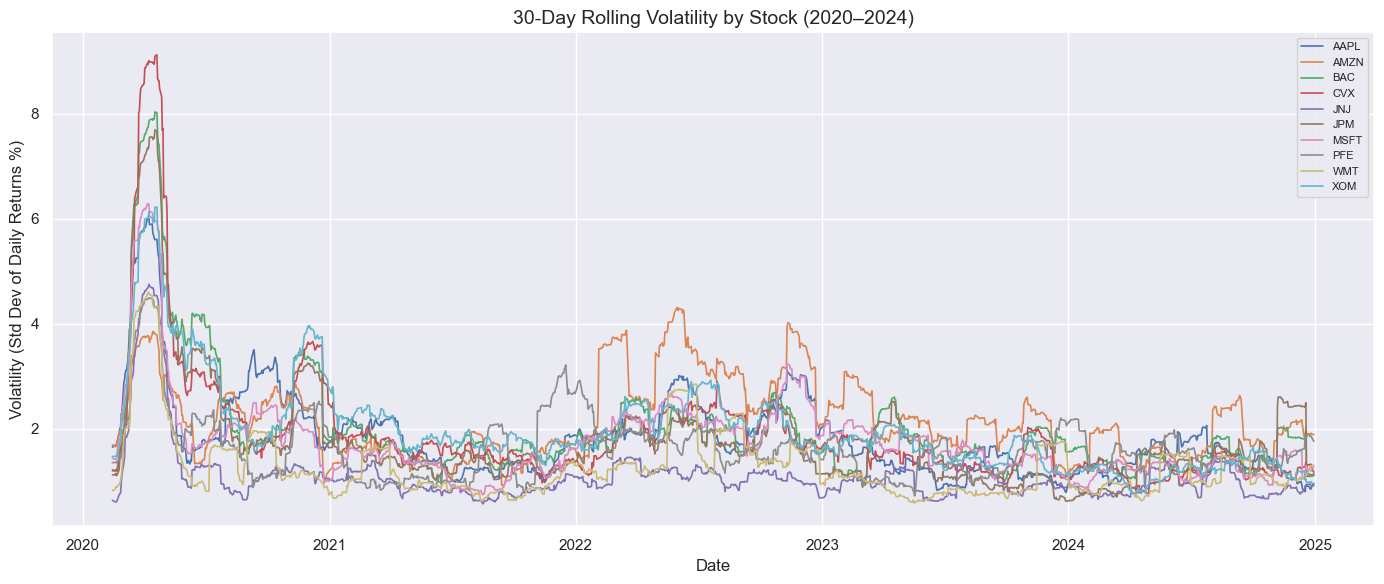

In [15]:
daily_returns = df.pct_change()
volatility = daily_returns.rolling(window=30).std() * 100

plt.figure(figsize=(14, 6))
for col in volatility.columns:
    plt.plot(volatility.index, volatility[col], label=col, linewidth=1.2)

plt.title("30-Day Rolling Volatility by Stock (2020–2024)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Daily Returns %)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("volatility.png", dpi=150)
plt.show()

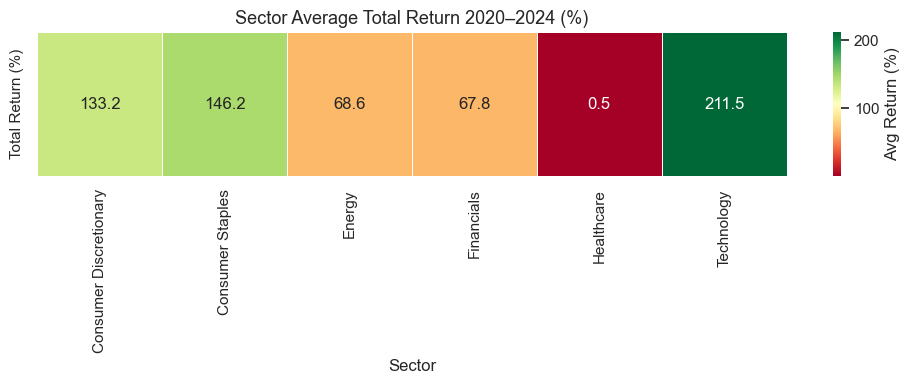

In [23]:
# Total return % over full period
total_return = ((df.iloc[-1] - df.iloc[0]) / df.iloc[0] * 100).reset_index()
total_return.columns = ["Stock", "Total Return (%)"]
total_return["Sector"] = total_return["Stock"].map(tickers)

sector_avg = total_return.groupby("Sector")["Total Return (%)"].mean().reset_index()

plt.figure(figsize=(10, 4))
pivot = sector_avg.set_index("Sector").T
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "Avg Return (%)"})
plt.title("Sector Average Total Return 2020–2024 (%)", fontsize=13)
plt.tight_layout()
plt.savefig("sector_heatmap.png", dpi=150)
plt.show()

In [19]:
# Export cleaned daily closing prices
df.reset_index().to_csv("sp500_closing_prices.csv", index=False)

# Export daily returns
daily_returns.reset_index().to_csv("sp500_daily_returns.csv", index=False)

# Export total returns with sector
total_return.to_csv("sp500_total_returns.csv", index=False)

print("✅ Files exported successfully")

✅ Files exported successfully
